In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Known constants
d = 3e-6                 # bead diameter [m]
nu = 1.002e-3            # viscosity of water [Pa*s]
beta = 3 * np.pi * nu * d
T = 295                  # temperature [K]

# Curve fit equation
def lorentzian(f, P0, f0):
    return (P0 * f0**2) / (f**2 + f0**2)

# Read the files in

def read_position_file(file_path):
    df = pd.read_csv(file_path, sep=r'\s+', header=1, engine='python')
    df.columns = ['placeholder', 'x', 'y', 'sum']

    # convert micrometers to meters
    x = df['x'].to_numpy(dtype=float) * 1e-6
    y = df['y'].to_numpy(dtype=float) * 1e-6

    return x, y

def read_power_file(file_path):
    df = pd.read_csv(
        file_path,
        sep=r'\s+',
        header=None,
        comment='#',
        engine='python'
    )
    df = df.replace({',': ''}, regex=True).astype(float)
    df.columns = ['f', 'Px', 'Py', 'Ptot']
    return df


# Main analysis for one current

def analyze_dataset(position_path, power_path, label="", use_axis="x"):
    # position data
    x, y = read_position_file(position_path)

    # variance
    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)

    # Power spectrum
    dfp = read_power_file(power_path)
    f = dfp['f'].to_numpy()

    if use_axis == "x":
        P = dfp['Px'].to_numpy()
        variance = var_x
    elif use_axis == "y":
        P = dfp['Py'].to_numpy()
        variance = var_y
    else:
        raise ValueError("use_axis must be 'x' or 'y'")

    # remove the negatives
    mask = np.isfinite(f) & np.isfinite(P) & (f > 0) & (P > 0)
    f_fit = f[mask]
    P_fit = P[mask]

    # restrict to a cleaner fitting window
    fit_window = (f_fit > 1) & (f_fit < 5000)
    f_fit = f_fit[fit_window]
    P_fit = P_fit[fit_window]

  # initial guesses
    P0_guess = np.max(P_fit)
    f0_guess = 50.0

    popt, pcov = curve_fit(
        lorentzian,
        f_fit,
        P_fit,
        p0=[P0_guess, f0_guess],
        bounds=(0, np.inf),
        maxfev=20000
    )

    P0_fit, f0_fit = popt

    # trap stiffness from corner frequency
    alpha = 2 * np.pi * beta * f0_fit

    # Boltzmann constant calculation:
    # (1/2) alpha <x^2> = (1/2) k_B T
    k_b = alpha * variance / T

    # plot
    plt.figure(figsize=(6,4))
    plt.loglog(f_fit, P_fit, '.', alpha=0.35, label=f'{label} data')
    plt.loglog(f_fit, lorentzian(f_fit, *popt), '-', label='Lorentzian fit')
    plt.xlabel("Frequency [Hz]")
    plt.ylabel(f"P{use_axis}(f)")
    plt.title(f"{label}")
    plt.legend()
    plt.show()


    # Plot the raw data of variation of x as a function of time
    dt = 1 / 131072  # sampling rate of the file
    t = np.arange(len(x)) * dt

    plt.figure(figsize=(7,4))
    plt.plot(t, x, lw=0.8)
    plt.xlabel("Time [s]")
    plt.ylabel("Variation x [m]")
    plt.title(f"{label}: Raw x(t)")
    plt.grid(True)
    plt.show()

    return {
        "label": label,
        "variance": variance,
        "P0": P0_fit,
        "f0": f0_fit,
        "alpha": alpha,
        "k_B": k_b
    }

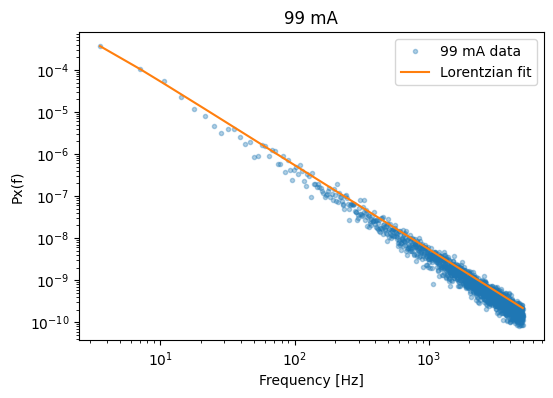

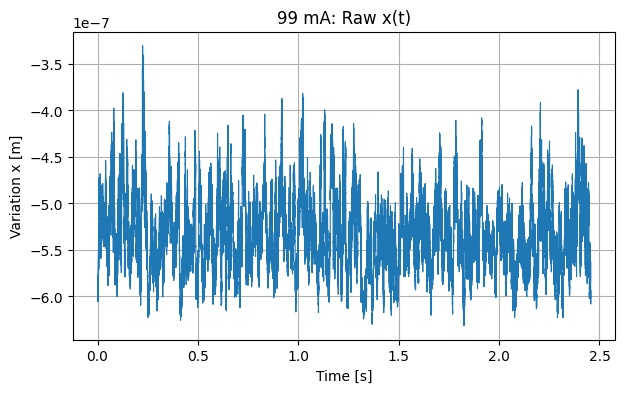

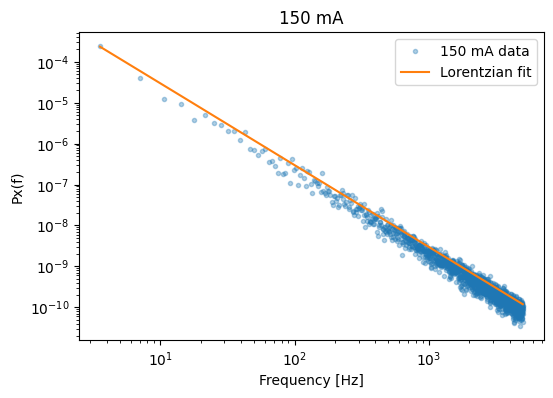

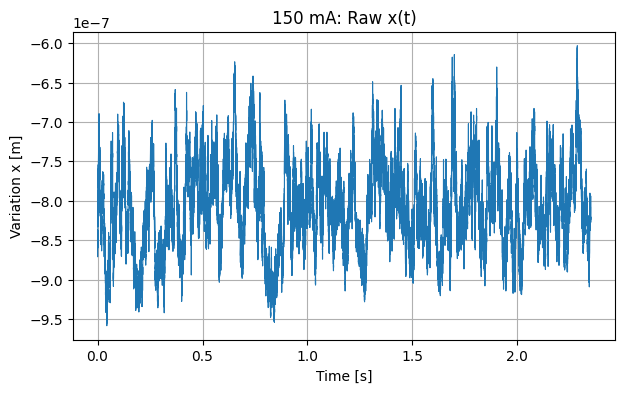

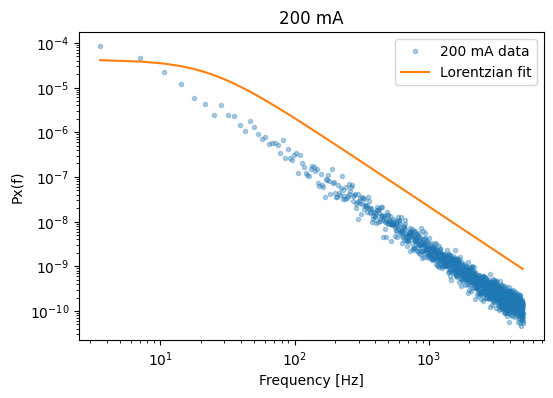

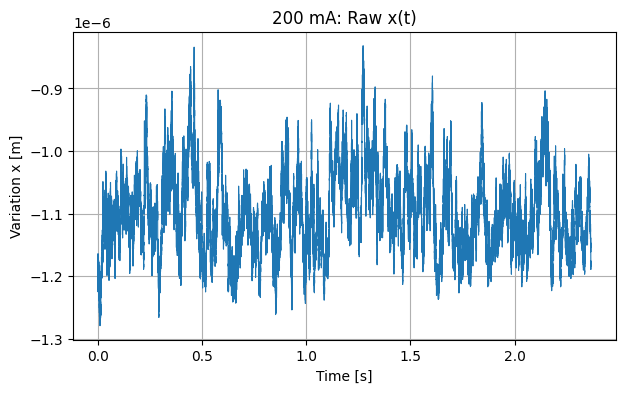

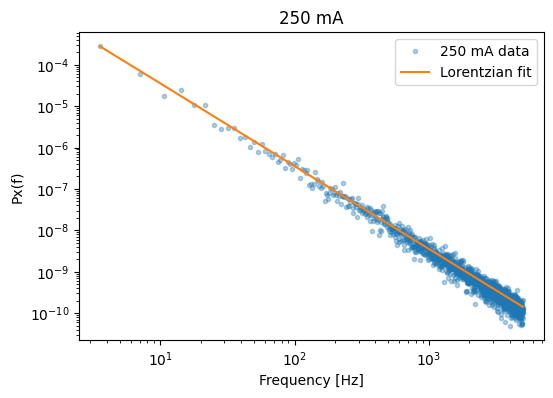

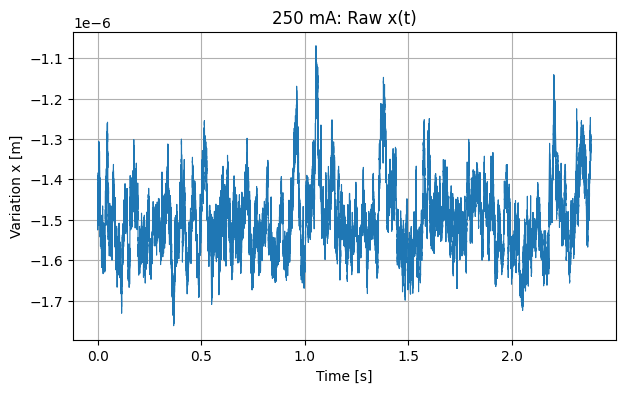

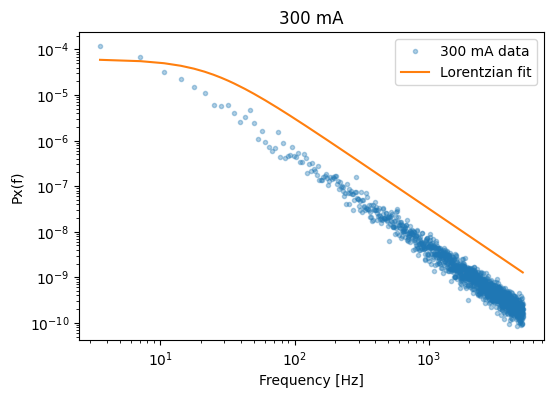

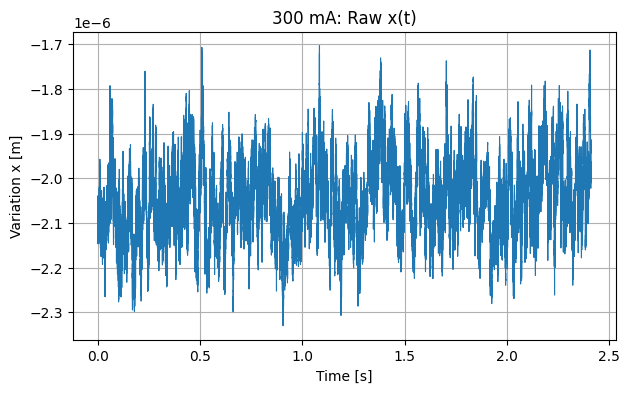

In [ ]:
results = []

results.append(analyze_dataset(
    "/content/drive/My Drive/AdvancedLab/BrownianMotion/Data/99mA_1.dat",
    "/content/drive/My Drive/AdvancedLab/BrownianMotion/Data/99mApower.FDdat",
    label="99 mA",
    use_axis="x"
))


results.append(analyze_dataset(
    "/content/drive/My Drive/AdvancedLab/BrownianMotion/Data/150mA_1.dat",
    "/content/drive/My Drive/AdvancedLab/BrownianMotion/Data/150mApower.FDdat",
    label="150 mA",
    use_axis="x"
))

results.append(analyze_dataset(
    "/content/drive/My Drive/AdvancedLab/BrownianMotion/Data/200mA_1.dat",
    "/content/drive/My Drive/AdvancedLab/BrownianMotion/Data/200mApower.FDdat",
    label="200 mA",
    use_axis="x"
))

results.append(analyze_dataset(
    "/content/drive/My Drive/AdvancedLab/BrownianMotion/Data/250mA_1.dat",
    "/content/drive/My Drive/AdvancedLab/BrownianMotion/Data/250mApower.FDdat",
    label="250 mA",
    use_axis="x"
))


results.append(analyze_dataset(
    "/content/drive/My Drive/AdvancedLab/BrownianMotion/Data/300mA_1.dat",
    "/content/drive/My Drive/AdvancedLab/BrownianMotion/Data/300mApower.FDdat",
    label="300 mA",
    use_axis="x"
))

In [ ]:
kb_vals = np.array([r["k_B"] for r in results])
print("Average experimental k_B =", np.mean(kb_vals))
print("Std dev =", np.std(kb_vals, ddof=1))
print("Accepted k_B =", 1.380649e-23)

Average experimental k_B = 3.4402568043549044e-23
Std dev = 4.846472504654471e-23
Accepted k_B = 1.380649e-23


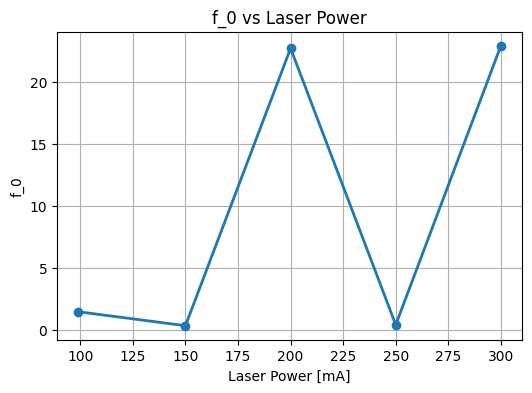

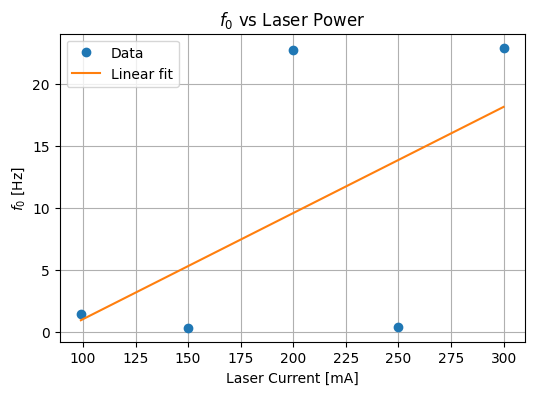

Slope = 0.08571138143282717


In [ ]:
# Plot f_0 as a function of laser power
currents = np.array([99, 150, 200, 250, 300])  # mA

f0_vals = np.array([r["f0"] for r in results])

plt.figure(figsize=(6,4))
plt.plot(currents, f0_vals, 'o-', lw=2)

plt.xlabel("Laser Power [mA]")
plt.ylabel("f_0")
plt.title("f_0 vs Laser Power")
plt.grid(True)

# Add a linear fit to show linear relationship
coeffs = np.polyfit(currents, f0_vals, 1)
fit_line = np.polyval(coeffs, currents)

plt.figure(figsize=(6,4))
plt.plot(currents, f0_vals, 'o', label="Data")
plt.plot(currents, fit_line, '-', label="Linear fit")

plt.xlabel("Laser Current [mA]")
plt.ylabel("$f_0$ [Hz]")
plt.title("$f_0$ vs Laser Power")
plt.legend()
plt.grid(True)

plt.show()

print("Slope =", coeffs[0])

In [ ]:
print(results)

[{'label': '99 mA', 'variance': np.float64(1.5828108056828919e-15), 'P0': np.float64(0.002489865521965782), 'f0': np.float64(1.476774527561867), 'alpha': np.float64(2.6287795327310176e-07), 'k_B': np.float64(1.4104612373439587e-24)}, {'label': '150 mA', 'variance': np.float64(3.0658059451880727e-15), 'P0': np.float64(0.024881910978830215), 'f0': np.float64(0.3461113433419114), 'alpha': np.float64(6.161065202860754e-08), 'k_B': np.float64(6.40292553478707e-25)}, {'label': '200 mA', 'variance': np.float64(4.32733068377546e-15), 'P0': np.float64(4.1990740912622714e-05), 'f0': np.float64(22.751487373338804), 'alpha': np.float64(4.04995097287901e-06), 'k_B': np.float64(5.940839699229023e-23)}, {'label': '250 mA', 'variance': np.float64(8.002273027860325e-15), 'P0': np.float64(0.020149706286408206), 'f0': np.float64(0.4206618935639028), 'alpha': np.float64(7.488126016273902e-08), 'k_B': np.float64(2.0312552152287402e-24)}, {'label': '300 mA', 'variance': np.float64(7.833603342465919e-15), 'P

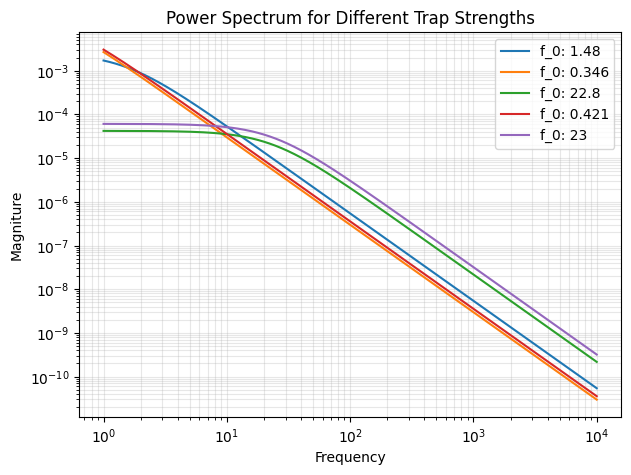

In [ ]:
# Put all of the fits together on one plot
import numpy as np
import matplotlib.pyplot as plt

def lorentzian(f, P0, f0):
    return (P0 * f0**2) / (f**2 + f0**2)

plt.figure(figsize=(7,5))

for r in results:
    P0 = r["P0"]
    f0 = r["f0"]

    # smooth frequency grid for curved fitted line
    f_smooth = np.logspace(0, 4, 500)   # 10^0 to 10^4 Hz
    P_fit = lorentzian(f_smooth, P0, f0)

    plt.loglog(f_smooth, P_fit, label=f'f_0: {f0:.3g}')

plt.xlabel("Frequency")
plt.ylabel("Magniture")
plt.title("Power Spectrum for Different Trap Strengths")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

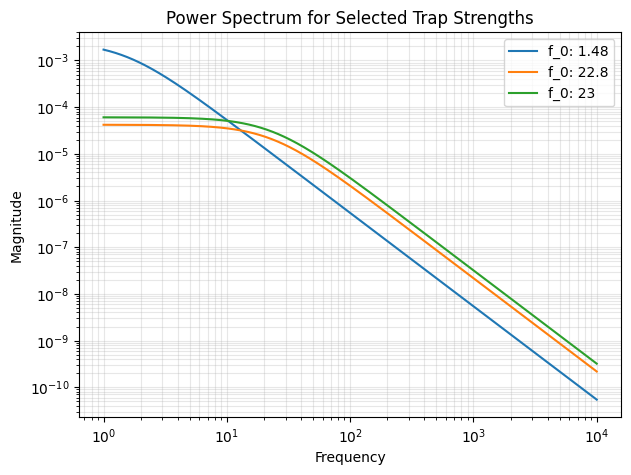

In [ ]:
def lorentzian(f, P0, f0):
    return (P0 * f0**2) / (f**2 + f0**2)

plt.figure(figsize=(7,5))


selected_f0 = ["99", "200", "300"]

for r in results:
    if not any(s in r["label"] for s in selected_f0):
        continue

    P0 = r["P0"]
    f0 = r["f0"]

    f_smooth = np.logspace(0, 4, 500)
    P_fit = lorentzian(f_smooth, P0, f0)

    plt.loglog(f_smooth, P_fit, label=f'f_0: {f0:.3g}')

plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.title("Power Spectrum for Selected Trap Strengths")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()